# 03 — Model Training

## KKBOX Customer Churn Prediction Platform

### Objective

Notebook này phân tích kết quả của **QT4 — Model Development & Training**.

Production training pipeline được triển khai trong:

```text
src/kkbox_churn_prediction/modeling/
├── data.py
├── preprocessing.py
├── metrics.py
└── train.py


---

# CELL 2 — Markdown

```markdown
## 1. Setup

In [19]:
import json

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from kkbox_churn_prediction.config import (
    FEATURE_NAMES_PATH,
    MODEL_SPLITS_PATH,
    PREPROCESSOR_PATH,
    TRAINING_METADATA_PATH,
    TRAINING_RESULTS_PATH,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

## 2. Load Training Artifacts

QT4 đã lưu các artifact phục vụ reproducibility và model evaluation:

```text
models/
├── preprocessor.joblib
├── preprocessed_feature_names.json
├── dummy_classifier.joblib
├── logistic_regression.joblib
├── random_forest.joblib
├── lightgbm.joblib
├── validation_results.json
└── training_metadata.json

In [20]:
with open(
    TRAINING_METADATA_PATH,
    encoding="utf-8",
) as file:
    metadata = json.load(file)

metadata

{'random_state': 42,
 'source_dataset': '/home/namdp/Documents/AI_Projects/kkbox-churn-prediction/data/processed/train_features.parquet',
 'total_rows': 970960,
 'train_rows': 679672,
 'validation_rows': 145644,
 'test_rows': 145644,
 'train_churn_rate': 0.08994191315811156,
 'validation_churn_rate': 0.08994534618659196,
 'test_churn_rate': 0.08993848012963115,
 'raw_feature_count': 40,
 'processed_feature_count': 88,
 'negative_train_samples': 618541,
 'positive_train_samples': 61131,
 'scale_pos_weight': 10.118286957517462,
 'test_evaluated': False,
 'primary_validation_metric': 'pr_auc',
 'secondary_validation_metric': 'roc_auc'}

In [21]:
with open(
    TRAINING_RESULTS_PATH,
    encoding="utf-8",
) as file:
    results = json.load(file)

results

{'dummy': {'train': {'pr_auc': 0.08994191315811156, 'roc_auc': 0.5},
  'validation': {'pr_auc': 0.08994534618659196, 'roc_auc': 0.5}},
 'logistic_regression': {'train': {'pr_auc': 0.8029583984322994,
   'roc_auc': 0.9695432460666905},
  'validation': {'pr_auc': 0.8120004383129504, 'roc_auc': 0.9694572679422487}},
 'random_forest': {'train': {'pr_auc': 0.9351891059099467,
   'roc_auc': 0.9901075254812786},
  'validation': {'pr_auc': 0.9175438728256777, 'roc_auc': 0.986454451478708}},
 'lightgbm': {'train': {'pr_auc': 0.9504842561384791,
   'roc_auc': 0.9938789512943469},
  'validation': {'pr_auc': 0.9344557863761336, 'roc_auc': 0.9897519072450893},
  'best_iteration': 786,
  'scale_pos_weight': 10.118286957517462}}

## 3. Dataset Split Analysis

Processed dataset được chia thành:

```text
70% Train
15% Validation
15% Test

In [22]:
split_summary = pd.DataFrame(
    {
        "split": [
            "Train",
            "Validation",
            "Test",
        ],
        "rows": [
            metadata["train_rows"],
            metadata["validation_rows"],
            metadata["test_rows"],
        ],
        "churn_rate": [
            metadata["train_churn_rate"],
            metadata["validation_churn_rate"],
            metadata["test_churn_rate"],
        ],
    }
)

split_summary

,split,rows,churn_rate
0,Train,679672,0.0899
1,Validation,145644,0.0899
2,Test,145644,0.0899


In [23]:
split_summary["rows"].sum()

np.int64(970960)

In [24]:
splits = pd.read_parquet(
    MODEL_SPLITS_PATH
)

splits.head()

,msno,split
0,XNEbIl9Mh3jza5+nGorg0LMWITvdVyTdLlZ6wkhv9Uk=,train
1,QVBsUVftLrm0p+HnfeaaVRCz9fRiGA5/prkqWjKZbhA=,train
2,TtUfnWB09iGPa/M20SUUbIOjkb1JOgzyrEMa+ETFY3I=,train
3,0K6M3ckg2f8Tw5Mn/Nr20EYF4H1FvfgY9KvTmo1VOhQ=,train
4,Qfi3C3D4EaNaCaYTCCr1lQ6f3PchrbT5LcuOaSpngww=,train


In [25]:
splits["split"].value_counts()

split
train         679672
validation    145644
test          145644
Name: count, dtype: int64

In [26]:
split_integrity = pd.Series(
    {
        "rows": len(splits),
        "unique_msno": splits["msno"].nunique(),
        "duplicate_msno": splits["msno"].duplicated().sum(),
        "missing_msno": splits["msno"].isna().sum(),
    }
)

split_integrity

rows              970960
unique_msno       970960
duplicate_msno         0
missing_msno           0
dtype: int64

### Split Findings

- Tổng cộng **970,960 users** được phân bổ vào ba split.
- Train: **679,672 users**.
- Validation: **145,644 users**.
- Test: **145,644 users**.
- Không có user xuất hiện ở nhiều split.
- Churn rate của cả ba split đều khoảng **8.99%**.
- Stratified splitting hoạt động đúng.
- Test split đã được cố định bằng `model_splits.parquet`.

Điều này đảm bảo QT5 có thể sử dụng chính xác cùng một test set.

## 4. Class Imbalance

Target distribution vẫn thể hiện rõ class imbalance:

```text
Non-churn ≈ 91.01%
Churn     ≈ 8.99%

In [27]:
class_summary = pd.DataFrame(
    {
        "split": [
            "Train",
            "Validation",
            "Test",
        ],
        "churn_rate": [
            metadata["train_churn_rate"],
            metadata["validation_churn_rate"],
            metadata["test_churn_rate"],
        ],
    }
)

class_summary

,split,churn_rate
0,Train,0.0899
1,Validation,0.0899
2,Test,0.0899


## 5. Preprocessing Analysis

QT3 tạo ra **40 raw candidate features**.

QT4 preprocessing gồm:

### Numeric features

```text
Missing values
      ↓
Median Imputation
      ↓
Missing Indicator
      ↓
StandardScaler

In [28]:
preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",1.0
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [29]:
with open(
    FEATURE_NAMES_PATH,
    encoding="utf-8",
) as file:
    processed_feature_names = json.load(file)

print(
    "Raw feature count:",
    metadata["raw_feature_count"],
)

print(
    "Processed feature count:",
    metadata["processed_feature_count"],
)

print()

processed_feature_names[:20]

Raw feature count: 40
Processed feature count: 88



['numeric__has_member_data',
 'numeric__has_transaction_data',
 'numeric__has_log_data',
 'numeric__age',
 'numeric__account_age_days',
 'numeric__transaction_count',
 'numeric__total_paid',
 'numeric__avg_paid',
 'numeric__min_paid',
 'numeric__max_paid',
 'numeric__avg_plan_price',
 'numeric__avg_plan_days',
 'numeric__avg_discount',
 'numeric__auto_renew_rate',
 'numeric__last_auto_renew',
 'numeric__cancel_count',
 'numeric__cancel_rate',
 'numeric__last_is_cancel',
 'numeric__days_since_last_transaction',
 'numeric__active_days']

### Preprocessing Findings

- Raw modeling dataset có **40 candidate features**.
- Sau imputation indicators và one-hot encoding, feature matrix có **88 features**.
- Numeric missing values được xử lý bằng median học từ Train.
- Missing indicators giúp model nhận biết việc dữ liệu bị thiếu.
- Categorical features được one-hot encoded.
- Unknown categories trong future data có thể được xử lý bằng `handle_unknown="ignore"`.
- Không có preprocessing parameter nào được fit bằng Validation hoặc Test.

## 6. Build Model Comparison Table

In [30]:
comparison_rows = []

for model_name, model_result in results.items():
    comparison_rows.append(
        {
            "model": model_name,

            "train_pr_auc": (
                model_result["train"]["pr_auc"]
            ),

            "validation_pr_auc": (
                model_result["validation"]["pr_auc"]
            ),

            "train_roc_auc": (
                model_result["train"]["roc_auc"]
            ),

            "validation_roc_auc": (
                model_result["validation"]["roc_auc"]
            ),
        }
    )

comparison = pd.DataFrame(
    comparison_rows
)

comparison

,model,train_pr_auc,validation_pr_auc,train_roc_auc,validation_roc_auc
0,dummy,0.0899,0.0899,0.5000,0.5000
1,logistic_regression,0.8030,0.8120,0.9695,0.9695
2,random_forest,0.9352,0.9175,0.9901,0.9865
3,lightgbm,0.9505,0.9345,0.9939,0.9898


In [31]:
comparison["pr_auc_gap"] = (
    comparison["train_pr_auc"]
    - comparison["validation_pr_auc"]
)

comparison["roc_auc_gap"] = (
    comparison["train_roc_auc"]
    - comparison["validation_roc_auc"]
)

comparison = comparison.sort_values(
    "validation_pr_auc",
    ascending=False,
).reset_index(drop=True)

comparison

,model,train_pr_auc,validation_pr_auc,train_roc_auc,validation_roc_auc,pr_auc_gap,roc_auc_gap
0,lightgbm,0.9505,0.9345,0.9939,0.9898,0.0160,0.0041
1,random_forest,0.9352,0.9175,0.9901,0.9865,0.0176,0.0037
2,logistic_regression,0.8030,0.8120,0.9695,0.9695,-0.0090,0.0001
3,dummy,0.0899,0.0899,0.5000,0.5000,-0.0000,0.0000


## 7. Dummy Baseline

In [32]:
comparison[
    comparison["model"] == "dummy"
]

,model,train_pr_auc,validation_pr_auc,train_roc_auc,validation_roc_auc,pr_auc_gap,roc_auc_gap
3,dummy,0.0899,0.0899,0.5000,0.5000,-0.0000,0.0000


### DummyClassifier Findings

DummyClassifier đạt:

- Train PR-AUC: **0.0899**
- Validation PR-AUC: **0.0899**
- Train ROC-AUC: **0.5000**
- Validation ROC-AUC: **0.5000**

PR-AUC gần đúng churn prevalence (~8.99%), đúng với kỳ vọng của một model không học predictive patterns.

DummyClassifier cung cấp lower-bound baseline cho các model thực tế.

## 8. Logistic Regression

In [33]:
comparison[
    comparison["model"]
    == "logistic_regression"
]

,model,train_pr_auc,validation_pr_auc,train_roc_auc,validation_roc_auc,pr_auc_gap,roc_auc_gap
2,logistic_regression,0.8030,0.8120,0.9695,0.9695,-0.0090,0.0001


### Logistic Regression Findings

Logistic Regression đạt:

- Train PR-AUC: **0.8030**
- Validation PR-AUC: **0.8120**
- Train ROC-AUC: **0.9695**
- Validation ROC-AUC: **0.9695**

Model vượt Dummy baseline rất lớn, cho thấy feature set chứa predictive signal mạnh ngay cả với một linear classifier.

Validation performance gần Train performance nên không có dấu hiệu overfitting đáng kể.

Training xuất hiện `ConvergenceWarning`, nghĩa là solver đạt `max_iter` trước khi coefficients hội tụ hoàn toàn. Vì Logistic Regression chỉ đóng vai trò linear baseline, model vẫn được giữ lại để benchmark nhưng không được xem là candidate chính.

## 9. Random Forest

In [34]:
comparison[
    comparison["model"]
    == "random_forest"
]

,model,train_pr_auc,validation_pr_auc,train_roc_auc,validation_roc_auc,pr_auc_gap,roc_auc_gap
1,random_forest,0.9352,0.9175,0.9901,0.9865,0.0176,0.0037


### Random Forest Findings

Random Forest đạt:

- Train PR-AUC: **0.9352**
- Validation PR-AUC: **0.9175**
- Train ROC-AUC: **0.9901**
- Validation ROC-AUC: **0.9865**

Generalization gaps:

- PR-AUC gap: **0.0176**
- ROC-AUC gap: **0.0037**

Random Forest vượt Logistic Regression rõ rệt, cho thấy nonlinear relationships và feature interactions có giá trị đáng kể trong churn prediction.

Train performance cao hơn Validation performance, cho thấy overfitting nhẹ, nhưng mức gap hiện tại chưa nghiêm trọng.

Random Forest được giữ làm candidate phụ cho QT5.

## 10. LightGBM

In [35]:
comparison[
    comparison["model"]
    == "lightgbm"
]

,model,train_pr_auc,validation_pr_auc,train_roc_auc,validation_roc_auc,pr_auc_gap,roc_auc_gap
0,lightgbm,0.9505,0.9345,0.9939,0.9898,0.0160,0.0041


In [36]:
lightgbm_result = results["lightgbm"]

pd.Series(
    {
        "best_iteration": (
            lightgbm_result["best_iteration"]
        ),
        "scale_pos_weight": (
            lightgbm_result["scale_pos_weight"]
        ),
    }
)

best_iteration     786.0000
scale_pos_weight    10.1183
dtype: float64

### LightGBM Findings

LightGBM đạt:

- Train PR-AUC: **0.9505**
- Validation PR-AUC: **0.9345**
- Train ROC-AUC: **0.9939**
- Validation ROC-AUC: **0.9898**

Generalization gaps:

- PR-AUC gap: **0.0160**
- ROC-AUC gap: **0.0041**

Class imbalance được xử lý bằng:

```text
scale_pos_weight = 10.1183

## 11. Validation PR-AUC Comparison

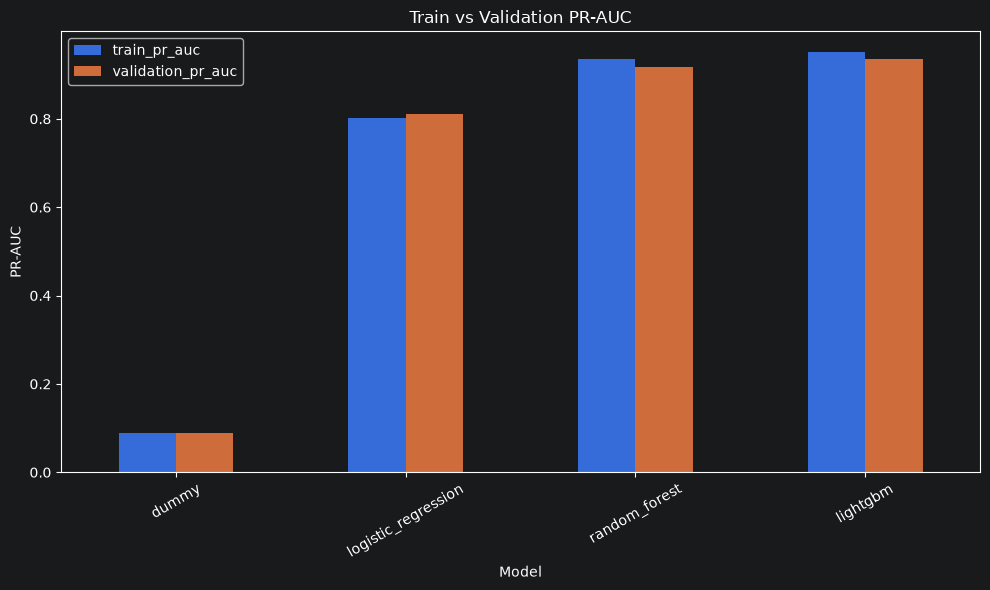

In [37]:
plot_df = comparison.sort_values(
    "validation_pr_auc"
)

ax = plot_df.plot(
    x="model",
    y=[
        "train_pr_auc",
        "validation_pr_auc",
    ],
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "Train vs Validation PR-AUC"
)

ax.set_ylabel(
    "PR-AUC"
)

ax.set_xlabel(
    "Model"
)

plt.xticks(
    rotation=30,
)

plt.tight_layout()
plt.show()

## 12. ROC-AUC Comparison

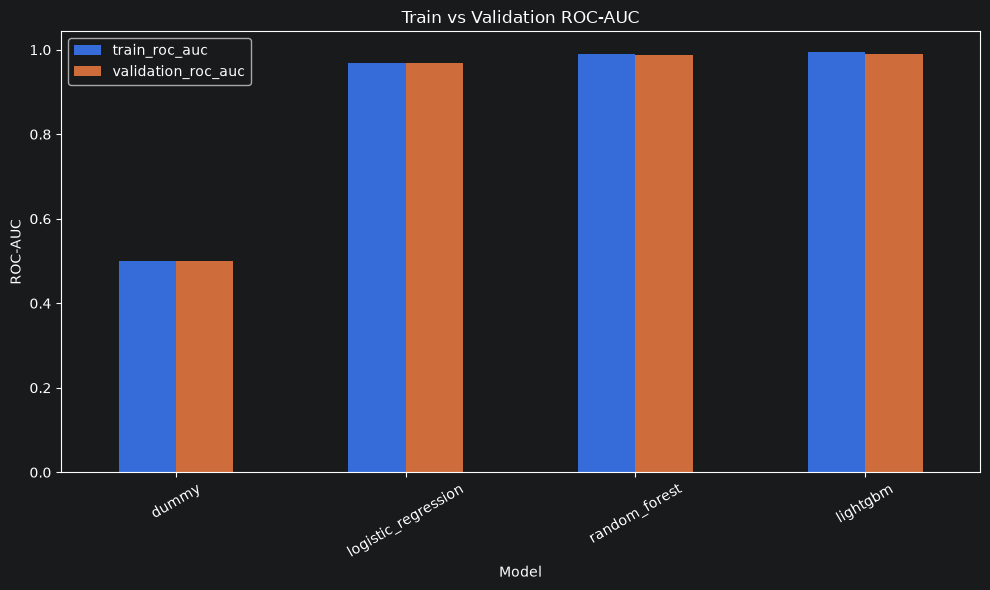

In [38]:
plot_df = comparison.sort_values(
    "validation_roc_auc"
)

ax = plot_df.plot(
    x="model",
    y=[
        "train_roc_auc",
        "validation_roc_auc",
    ],
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "Train vs Validation ROC-AUC"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_xlabel(
    "Model"
)

plt.xticks(
    rotation=30,
)

plt.tight_layout()
plt.show()

## 13. Generalization Analysis

Generalization gap được tính bằng:

```text
Train score - Validation score

In [39]:
comparison[
    [
        "model",
        "pr_auc_gap",
        "roc_auc_gap",
    ]
].sort_values(
    "pr_auc_gap",
    ascending=False,
)

,model,pr_auc_gap,roc_auc_gap
1,random_forest,0.0176,0.0037
0,lightgbm,0.0160,0.0041
3,dummy,-0.0000,0.0000
2,logistic_regression,-0.0090,0.0001


### Generalization Findings

#### LightGBM

```text
PR-AUC gap  = 0.0160
ROC-AUC gap = 0.0041

## 14. Relative Improvement over Baseline

In [40]:
dummy_pr_auc = float(
    comparison.loc[
        comparison["model"] == "dummy",
        "validation_pr_auc",
    ].iloc[0]
)

comparison["pr_auc_lift_over_dummy"] = (
    comparison["validation_pr_auc"]
    / dummy_pr_auc
)

comparison[
    [
        "model",
        "validation_pr_auc",
        "pr_auc_lift_over_dummy",
    ]
]

,model,validation_pr_auc,pr_auc_lift_over_dummy
0,lightgbm,0.9345,10.3892
1,random_forest,0.9175,10.2011
2,logistic_regression,0.8120,9.0277
3,dummy,0.0899,1.0000


## 15. Candidate Model Selection

Primary validation metric:

```text
PR-AUC

## 16. QT4 Validation Checks

In [41]:
checks = {
    "split_file_exists": (
        MODEL_SPLITS_PATH.exists()
    ),

    "preprocessor_exists": (
        PREPROCESSOR_PATH.exists()
    ),

    "training_metadata_exists": (
        TRAINING_METADATA_PATH.exists()
    ),

    "training_results_exists": (
        TRAINING_RESULTS_PATH.exists()
    ),

    "all_users_in_splits": (
        len(splits) == 970_960
    ),

    "unique_users_in_splits": (
        splits["msno"].is_unique
    ),

    "raw_feature_count_40": (
        metadata["raw_feature_count"] == 40
    ),

    "processed_feature_count_88": (
        metadata["processed_feature_count"] == 88
    ),

    "test_not_evaluated": (
        metadata["test_evaluated"] is False
    ),

    "lightgbm_best_validation_model": (
        comparison.iloc[0]["model"]
        == "lightgbm"
    ),
}

pd.Series(
    checks,
    name="passed",
)

split_file_exists                 True
preprocessor_exists               True
training_metadata_exists          True
training_results_exists           True
all_users_in_splits               True
unique_users_in_splits            True
raw_feature_count_40              True
processed_feature_count_88        True
test_not_evaluated                True
lightgbm_best_validation_model    True
Name: passed, dtype: bool

## 17. Automated Tests

QT4 automated tests đã được chạy bằng:

```bash
uv run pytest -v

# 18. Key Findings

## Dataset

Processed training dataset:

```text
970,960 users
40 raw candidate features


---

# CELL 50 — Markdown: Next Steps

```markdown
# 19. Next Steps — QT5 Model Evaluation & Selection

QT5 sẽ sử dụng Validation set để:

1. Phân tích Precision-Recall Curve.
2. Phân tích ROC Curve.
3. Tìm classification threshold phù hợp.
4. Tính Precision.
5. Tính Recall.
6. Tính F1-score.
7. Phân tích Confusion Matrix.
8. Đánh giá False Positive / False Negative.
9. Kiểm tra probability calibration.
10. Tính Brier Score.
11. Thực hiện error analysis.
12. Phân tích feature importance / SHAP.
13. So sánh LightGBM và Random Forest nếu cần.

Sau khi toàn bộ model decisions đã được khóa:

```text
model
hyperparameters
threshold
calibration strategy